# Model

Speedy + Slab Ocean Model

In [1]:
import os
#os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/t2hsu/projects/jax-gcm
Add Path:  /home/t2hsu/projects/jax-esm


In [3]:
import numpy as np
import xarray as xr
import pandas as pd

from collections import namedtuple

#import jcm
#from jcm.model import Model, get_coords
#from jcm.boundaries import initialize_boundaries

from jax_esm.Coupler import Coupler
from jax_esm.components.base import ComponentConfig
from jax_esm.components.Speedy import Speedy
from jax_esm.components.SlabOceanModel import SlabOceanModel
#from jax_esm.components.SlabAtmosphereModel import SlabAtmosphereModel
from jax_esm.components.FluxModel import FluxModel

Path exist:  /home/t2hsu/projects/jax-gcm
Path exist:  /home/t2hsu/projects/jax-esm


## Create Model

In [4]:
total_simulation_time =   3 * 86400.0 # sec
coupler_time_step      =  86400.0  # sec
coupler_steps = int(total_simulation_time / coupler_time_step)

atm_substeps          =  48           # count
atm_save_interval     =  coupler_time_step / atm_substeps # coupler_time_step # sec

ocn_substeps          =  1            # count
ocn_save_interval     = 24 *  3600.0  # sec

flx_substeps          =  1            # count
flx_save_interval     = 24 *  3600.0  # sec

In [5]:
# Coupler Config
config_master = dict(
    total_simulation_time = total_simulation_time,
    time_step = coupler_time_step,
)

# Atmosphere model
config_atm = ComponentConfig(
    name = "atm",
    timestep = coupler_time_step,
    substeps = atm_substeps,
    save_interval = atm_save_interval,
    grid = None,
    params = None,
)

model_atm = Speedy(
    config = config_atm,
)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    timestep = coupler_time_step,
    substeps = ocn_substeps,
    save_interval = ocn_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
        relaxation_time = 86400.0 * 60,
    ),
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    timestep = coupler_time_step,
    substeps = flx_substeps,
    save_interval = flx_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
    ),
)
model_flx = FluxModel(config_flx)

type of init_state:  <class 'dinosaur.primitive_equations.State'>
(96, 48)
(96, 48)


In [6]:
coupler = Coupler(
    config = config_master,
    components = dict(
        flx = model_flx,
        atm = model_atm,
        ocn = model_ocn,
    ), 
)

fields =  [('flx', <class 'jax_esm.components.PhysicsState.FMState'>), ('atm', <class 'jcm.model.Predictions'>), ('ocn', <class 'jax_esm.components.PhysicsState.SOMState'>)]


## Setup Recorder

In [7]:
"""
record_names = ["atm.T", "ocn.T", "flx.lhflx", "flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa"]
recorder = {
    name: np.zeros((coupler_steps,))
    for name in record_names
}

def record(recorder, idx, cplstate, full_varnames):
    for full_varname in full_varnames:
        cmpt, varname = full_varname.split(".")
        recorder[full_varname][idx] = getattr( 
            getattr(cplstate, cmpt),
            varname)[0,0]
"""

'\nrecord_names = ["atm.T", "ocn.T", "flx.lhflx", "flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa"]\nrecorder = {\n    name: np.zeros((coupler_steps,))\n    for name in record_names\n}\n\ndef record(recorder, idx, cplstate, full_varnames):\n    for full_varname in full_varnames:\n        cmpt, varname = full_varname.split(".")\n        recorder[full_varname][idx] = getattr( \n            getattr(cplstate, cmpt),\n            varname)[0,0]\n'

# Run the Model

In [8]:
import time

start_time = time.time()


init_cplstate = coupler.state.copy()
cplstate = init_cplstate.copy()
for step in range(coupler_steps):
    print(f"Coupler Step: {step:d}/{coupler_steps:d}")
    cpl_forward_func = coupler.genForwardFunc(first_time=step==0)
    cplstate = cpl_forward_func(cplstate)
    #record(recorder, step, cplstate, record_names)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed Time: {elapsed_time} seconds")

Coupler Step: 0/3
Coupler Step: 1/3
Coupler Step: 2/3
Elapsed Time: 24.954880714416504 seconds


(96, 48)


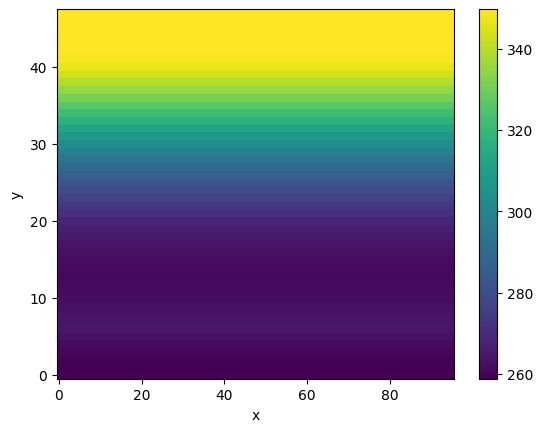

In [9]:
import xarray as xr

print(cplstate.flx.swflx_toa.shape)

da = xr.DataArray(
 data=np.array(cplstate.flx.hfluxn),
    dims=["x", "y", "n"],
    coords=dict(
    ),
)
da.isel(n=0).plot(x='x', y='y')

In [ ]:
print(cplstate.ocn.T.shape)

da = xr.DataArray(
 data=np.array(cplstate.ocn.mld),
    dims=["x", "y",],
    coords=dict(
    ),
)
da.plot(x='x', y='y')

In [ ]:
import numpy as np
import jax

t = np.array(cplstate.atm.times)

import pandas as pd

for _t in t:
    print("time: ", pd.Timestamp("1970-01-01") + pd.Timedelta(days = _t))

atm_model = coupler.components["atm"]
pred_ds = atm_model.model.predictions_to_xarray(cplstate.atm)


In [ ]:
dir(cplstate.atm.physics)

In [ ]:
pred_ds

print(dir(cplstate.atm.physics.shortwave_rad))
#print(atm_model.model.coords.)
print(cplstate.atm.physics.shortwave_rad.fsol.shape)

In [ ]:
# 4d var?
import jax
import jax.numpy as jnp
"""
total_forward_func = cpl_forward_func
for step in range(coupler_steps):
    #print(f"Composite Step: {step:d}/{coupler_steps:d}")
    def new_total_forward_func(cplstate, prev_fn = total_forward_func):
        return cpl_forward_func(prev_fn(cplstate))

    total_forward_func = new_total_forward_func

print("Jitting total_forward_func...")
total_forward_func = jax.jit(total_forward_func)
"""

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

def simple_moving_average(data, window_size):
    weights = np.ones(window_size) / window_size
    sma = np.convolve(data, weights, mode='same')
    return sma

plot_names = [
    ("atm.T", "ocn.T",),
    ("flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa", "flx.lhflx",),
]

N_plot_names = len(plot_names)

fig, ax = plt.subplots(N_plot_names, 1, figsize=(12, 3*N_plot_names))
smooth_window_half_size = 0
smooth_window = smooth_window_half_size * 2 + 1

for i, full_varnames in enumerate(plot_names):
    _ax = ax[i]
    for j, full_varname in enumerate(full_varnames):
        y = recorder[full_varname]
        y_smooth = simple_moving_average(y, smooth_window)
        y_smooth[:smooth_window_half_size] = np.nan
        y_smooth[len(y)-smooth_window_half_size:] = np.nan
        _ax.plot(range(len(y)), y_smooth, label=full_varname)
        
    if i == 0:
        trans = transforms.blended_transform_factory(_ax.transAxes, _ax.transData)
        _ax.plot([0, 1], [T_a, T_a], color="red", linestyle="dashed", transform=trans, label="$T^*_a$")
        _ax.plot([0, 1], [T_o, T_o], color="blue", linestyle="dashed", transform=trans, label="$T^*_o$")

    _ax.legend()
    _ax.grid()


plt.show()